In [1]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\InteractEst\\')
from EOsimsuite import EOsimsuite as EOsim
import estimateInteractParams as estInt

In [2]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [5]:
#2-species function test
Kms = np.array([[1.3,1,0.9],[1,0.7,1.1]]) #Proline auxotroph then tryptophan auxotroph
Ys = np.array([[20,0,1],[0,10,1]])
Cs = np.array([[0,0.04,-1],[0.05,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 0.4

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

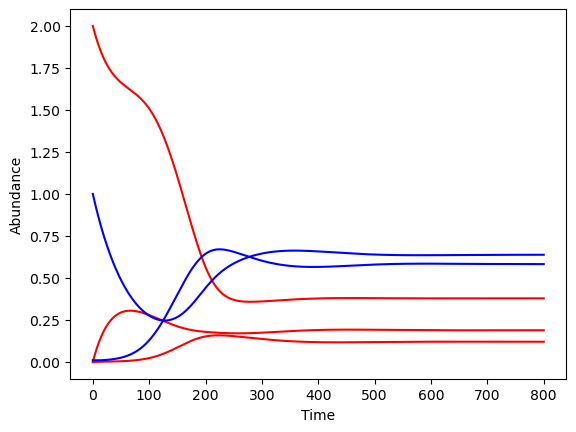

In [6]:
proConc = 0
tryConc = 0

B0 = np.array([0.01,1])

rIn = np.array([proConc,tryConc,2.0])
sysParams = {'rIn':rIn}
    
chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
chemSim.set_timeSettings(tSpan = [0,800], dt=0.1)
chemSim.set_dilSettings(D=0.015,transT=0.1)
chemSim.set_instInteract(instInteract)
chemSim.set_intrinsicGR(intrinsicGR)
    
chemSim.simEOmodel('Chemostat')

chemSim.plotSolutionTimecourse()

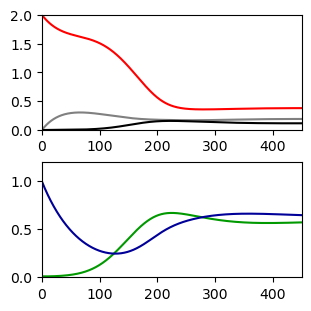

In [9]:
fig, axAr = plt.subplots(nrows = 2, ncols = 1, constrained_layout = True)
ax1=axAr[0]
ax2=axAr[1]

tList = np.arange(0,800,0.1)
ax1.plot(tList,chemSim.resTimeseries[0,:],color=(0.5,0.5,0.5))
ax1.plot(tList,chemSim.resTimeseries[1,:],'k')
ax1.plot(tList,chemSim.resTimeseries[2,:],'r')
ax2.plot(tList,chemSim.specTimeseries[0,:],color=(0,0.6,0))
ax2.plot(tList,chemSim.specTimeseries[1,:],color=(0,0,0.6))

ax1.set_xlim([0,450])
ax2.set_xlim([0,450])
ax1.set_ylim([0,2])
ax2.set_ylim([0,1.2])

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(3, 3)
plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\timeDependentResSpecs.pdf")

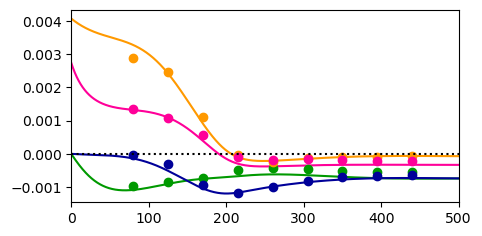

In [11]:
noT = 5000
list00 = np.zeros(noT)
list11 = np.zeros(noT)
list10 = np.zeros(noT)
list01 = np.zeros(noT)
for i in range(noT):
    rCurr = chemSim.resTimeseries[:,i]
    theoPredIntMat = chemSim.assembleIntMat(rCurr)
    list00[i] = theoPredIntMat[0,0]
    list11[i] = theoPredIntMat[1,1]
    list01[i] = theoPredIntMat[0,1]
    list10[i] = theoPredIntMat[1,0]

plt.plot(np.arange(noT)/10,list00,color=(0,0.6,0))
plt.plot(np.arange(noT)/10,list11,color=(0,0,0.6))
plt.plot(np.arange(noT)/10,list10,color=(1,0.6,0))
plt.plot(np.arange(noT)/10,list01,color=(1,0,0.6))

for i in range(1,10):
    rCurr = chemSim.resTimeseries[:,(i)*450+250]
    batchBase = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rCurr)
    batchBase.set_timeSettings(tSpan = [0,100],dt=0.02)

    expMeasIntMatEO = estInt.extractEOInteractMatFromBatch(batchBase,rCurr,0.1,0.01,50,0) #'Experimentally' measured interaction matrix using accelerations

    plt.plot(i*45+35,expMeasIntMatEO[0,0],'o',color=(0,0.6,0))
    plt.plot(i*45+35,expMeasIntMatEO[1,1],'o',color=(0,0,0.6))
    plt.plot(i*45+35,expMeasIntMatEO[1,0],'o',color=(1,0.6,0))
    plt.plot(i*45+35,expMeasIntMatEO[0,1],'o',color=(1,0,0.6))

plt.plot([0,500],[0,0],'k:')
plt.xlim([0,500])

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(5, 2.5)
plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\timeDependentInteractMeas.pdf")

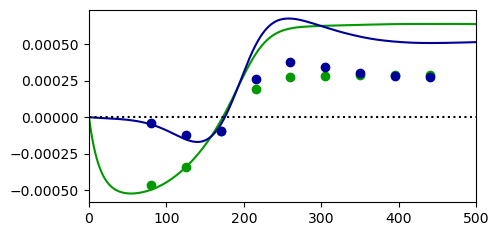

In [13]:
def extractAAfromBatch(batchBase,rIn,rStar,D,densSamp,noiseLevel):
    #Function that extracts the autogenic acceleration from batch culture data
    
    p = 0.9 #Ratio of rStar to rIn in test media
    outAAs = np.zeros(batchBase.B0.shape[0])
    
    for alphInd in range(batchBase.B0.shape[0]):
        thisB0 = np.zeros(batchBase.B0.shape[0])
        thisB0[alphInd] = 0.01
        
        #Measure intial GR at multiple points at rStar and rIn
        batchBase.set_initConds(thisB0,rStar,False)
        batchBase.simEOmodel('Batch')
        curveAlph = batchBase.specTimeseries[alphInd,:]
        noiseVec = np.random.normal(loc=0,scale=noiseLevel,size=(batchBase.specTimeseries.shape[1]))
        rStarAA = estInt.estimateInitGR(curveAlph,batchBase.dt,densSamp,10)
        
        batchBase.set_initConds(thisB0,rStar*p+(1-p)*rIn,False)
        batchBase.simEOmodel('Batch')
        curveAlph = batchBase.specTimeseries[alphInd,:]
        noiseVec = np.random.normal(loc=0,scale=noiseLevel,size=(batchBase.specTimeseries.shape[1]))
        rMidAA = estInt.estimateInitGR(curveAlph,batchBase.dt,densSamp,10)
        
        outAAs[alphInd] = (rMidAA - rStarAA)/(np.log(1/p)*(1/D))

    return outAAs

list0 = np.zeros(noT)
list1 = np.zeros(noT)
for i in range(noT):
    rCurr = chemSim.resTimeseries[:,i]
    theoPredAAs = chemSim.assembleGRvec(rCurr)
    list0[i] = theoPredAAs[0]
    list1[i] = theoPredAAs[1]

plt.plot(np.arange(noT)/10,list0,color=(0,0.6,0))
plt.plot(np.arange(noT)/10,list1,color=(0,0,0.6))

for i in range(1,10):
    rCurr = chemSim.resTimeseries[:,(i)*450+350]
    batchBase = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rCurr)
    batchBase.set_timeSettings(tSpan = [0,5000],dt=0.02)

    expMeasAAs = extractAAfromBatch(batchBase,sysParams['rIn'],rCurr,sysParams['D'],0.2,0.000)

    plt.plot(i*45+35,expMeasAAs[0],'o',color=(0,0.6,0))
    plt.plot(i*45+35,expMeasAAs[1],'o',color=(0,0,0.6))

plt.plot([0,500],[0,0],'k:')
plt.xlim([0,500])

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(5, 2.5)
plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\timeDependentAAMeas.pdf")